In [30]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [31]:
class FF_MNIST(torch.utils.data.Dataset):
    def __init__(self, partition, num_classes=10):
        self.mnist = self.get_MNIST_partition(partition)
        self.num_classes = num_classes
        self.uniform_label = torch.ones(self.num_classes) / self.num_classes

    def __getitem__(self, index):
        pos_sample, neg_sample, neutral_sample, class_label = self._generate_sample(
            index
        )

        inputs = {
            "pos_sample": pos_sample,
            "neg_sample": neg_sample,
            "natrual_sample": neutral_sample,
        }
        labels = {"class_labels": class_label}
        return inputs, labels

    def __len__(self):
        return len(self.mnist)

    def _get_pos_sample(self, sample, class_label):
        # one_hot_label = torch.nn.functional.one_hot(
        #     torch.tensor(class_label), num_classes=self.num_classes
        # )
        pos_sample = sample.clone()
        # pos_sample[:, 0, : self.num_classes] = one_hot_label
        return pos_sample

    def _get_neg_sample(self, sample, class_label):
        # Create randomly sampled one-hot label.
        # classes = list(range(self.num_classes))
        # classes.remove(class_label)  # Remove true label from possible choices.
        # wrong_class_label = np.random.choice(classes)
        # one_hot_label = torch.nn.functional.one_hot(
        #     torch.tensor(wrong_class_label), num_classes=self.num_classes
        # )
        neg_sample = sample.clone()
        mask = torch.bernoulli(torch.full_like(neg_sample, 0.2))

        neg_sample = neg_sample * mask
        # neg_sample[:, 0, : self.num_classes] = one_hot_label
        return neg_sample

    def _get_neutral_sample(self, z):
        # z[:, 0, : self.num_classes] = self.uniform_label
        return z

    def _generate_sample(self, index):
        # Get MNIST sample.
        sample, class_label = self.mnist[index]
        pos_sample = self._get_pos_sample(sample, class_label)
        neg_sample = self._get_neg_sample(sample, class_label)
        neutral_sample = self._get_neutral_sample(sample)
        return pos_sample, neg_sample, neutral_sample, class_label

    def get_MNIST_partition(self, partition):
        if partition in ["train", "val", "train_val"]:
            mnist = torchvision.datasets.MNIST(
                os.path.join("..", "data"),
                train=True,
                download=True,
                transform=torchvision.transforms.ToTensor(),
            )
        elif partition in ["test"]:
            mnist = torchvision.datasets.MNIST(
                os.path.join("..", "data"),
                train=False,
                download=True,
                transform=torchvision.transforms.ToTensor(),
            )
        else:
            raise NotImplementedError

        if partition == "train":
            mnist = torch.utils.data.Subset(mnist, range(50000))
        elif partition == "val":
            mnist = torchvision.datasets.MNIST(
                os.path.join("..", "data"),
                train=True,
                download=True,
                transform=torchvision.transforms.ToTensor(),
            )
            mnist = torch.utils.data.Subset(mnist, range(50000, 60000))

        return mnist

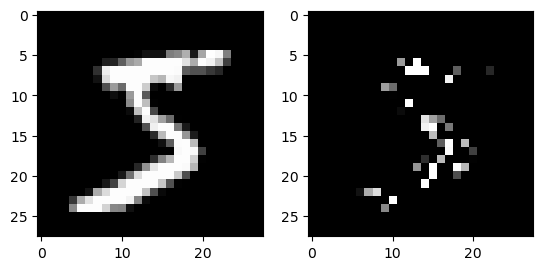

In [32]:
%matplotlib inline
dataset = FF_MNIST("train")

for inputs, labels in dataset:
    pos = inputs["pos_sample"][0].numpy()
    neg = inputs["neg_sample"][0].numpy()

    plt.subplot(1, 2, 1)
    plt.imshow(pos, cmap='binary_r')

    plt.subplot(1, 2, 2)
    plt.imshow(neg, cmap="binary_r")

    plt.show()
    
    break